In [1]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Lato"

from degree_and_size_distributions import edge_transition_matrix, asymptotic_edge_size_distribution

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

### Edge-Size-Intersections Joint Transition Matrix

In [2]:
k_max = 15
pars = {
    "eta"   : 0.4, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max),
}

pars.update({
    "gamma_vec" : pars["gamma"], 
    "beta_vec"  : pars["beta"]
})

pars["beta"][0:4] = 1/4
pars["gamma"][0:3] = 1/3

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

In [3]:
def approximation(k_max, pars):
    MC = m.MatrixConstructor(k_max, pars)
    M = MC.matrix_of_linear_map()
    EV = np.linalg.eig(M)
    print(f"Leading eigenvalue = {np.max(np.real(EV[0])):.6f}")
    v = np.abs(EV[1][:, np.argmax(np.real(EV[0]))])
    T = m.vec_to_tensor(v, k_max)
    
    return M, T

In [4]:
M, T = approximation(k_max, pars)

/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:223: RuntimeWarning: invalid value encountered in divide
  return binom(n_success, k_success)*binom(n - n_success, k - k_success)/binom(n, k)


Leading eigenvalue = 0.999999


##### Marginalization of Intersection Matrix 

We want to write a function that will extract the submatrix of the joint transition matrix that corresponds to $k = 0$. We would then marginalize that matrix along two axes to retrieve the transition matrix for the edge sizes. So, we need to figure out how to index into the joint transition matrix. This might involve a bit of research into how the `np.reshape` function actually works. In particular, we need to figure out the locations of triple indices of the form $(i,j,0)$ in the reshaped vector. There is some possibility that the result is very simple and that the answer is just the first $k_{\mathrm{max}}^2$ elements of the reshaped vector, corresponding to the top left corner of the matrix.

In [5]:
def marginalize_intersection_matrix(M):
    """
    should be the case that the final index k is changing most rapidly
    """
    k_max = int(np.round(np.pow(M.shape[0], 1/3)))
    ix = np.arange(0, k_max**3, k_max**2)
    m = M[ix][:,ix].copy()
    return(m)

In [6]:
m = marginalize_intersection_matrix(M)
m.shape

(15, 15)

(np.float64(-0.5), np.float64(14.5), np.float64(14.5), np.float64(-0.5))

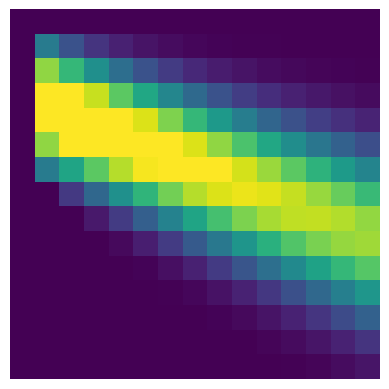

In [7]:
m = marginalize_intersection_matrix(M)
plt.imshow(m, cmap = "viridis", zorder = 10, vmin = 0, vmax = 0.1, interpolation = "none")
plt.gca().axis("off")

## Comparison to Edge-Size Transition Matrix

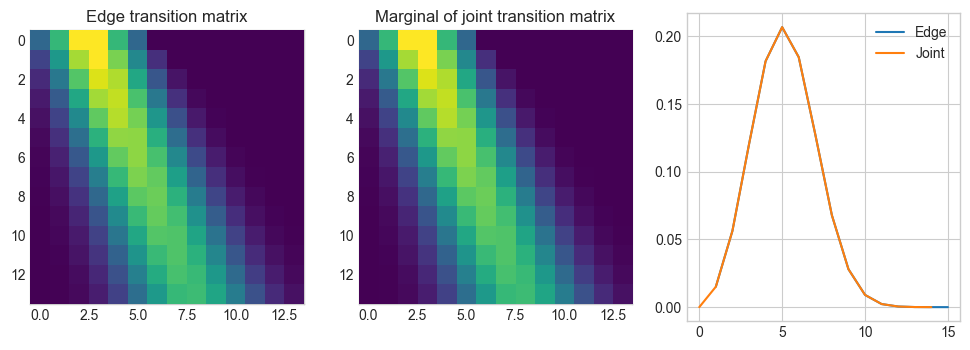

In [8]:
edge_m = edge_transition_matrix(pars, k_max)
edge_m = edge_m[:-1,:-1]

intersection_m = marginalize_intersection_matrix(M)

# need to truncate here because the tensor has zeroth index value corresponding to edges of size 0, which isn't real. Smallest real value is 1. 
intersection_m = intersection_m[1:,1:].T


fig, ax = plt.subplots(1, 3, figsize = (12, 4))

ax[0].imshow(edge_m, cmap = "viridis", zorder = 10)
ax[0].set(title = "Edge transition matrix")

ax[1].imshow(intersection_m, cmap = "viridis", zorder = 10)
ax[1].set(title = "Marginal of joint transition matrix")

v_edge = asymptotic_edge_size_distribution(pars, k_max)
v_intersection = 1/2*(T[:,:,0].sum(axis = (1)) + T[:,:,0].sum(axis = (0)))
v_intersection = v_intersection/v_intersection.sum()

ax[2].plot(np.arange(1, k_max + 1), v_edge, label = "Edge")
ax[2].plot(v_intersection, label = "Joint")
ax[2].legend()

In [9]:
# relative errors have a very interesting and predictable pattern, this is progress

# ok, so it looks like this portion of the intersection profile is indeed half as large as it should be, and this is indeed controlled by the 1/2 in the first term in the code (which corresponds to k = 0 and h = 0)

# this suggests to me that there is some kind of issue related to the *indexing*, which is perhaps expressed by the way in which the tensor as we construct has zeroth index value corresponding to the (fake) set of edges with sizes 0, whereas the tensor as the edge-size-distribution code is written has the zeroth index value correspnding to the (real) set of edges with sizes 1
intersection_m / edge_m

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_83479/3002083379.py:6: RuntimeWarning: invalid value encountered in divide
  intersection_m / edge_m


array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, nan, nan, nan, nan, nan, nan, nan,
        nan],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, nan, nan, nan, nan, nan, nan,
        nan],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, nan, nan, nan, nan, nan,
        nan],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, nan, nan, nan, nan,
        nan],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, nan, nan, nan,
        nan],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, nan, nan,
        nan],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, nan,
        nan],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
        nan],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
        0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
        0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
        0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 